## Limpieza de Datos

In [56]:
# !/usr/bin/env python3 
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [57]:
ruta = "../data/raw"

In [58]:
# Cargar los datos
categorias = pd.read_csv(ruta + '/categorias.csv')
clientes = pd.read_csv(ruta + '/clientes.csv')
metodos_pago = pd.read_csv(ruta + '/metodos_pago.csv')
productos = pd.read_csv(ruta + '/productos.csv')
ventas = pd.read_csv(ruta + '/ventas.csv')

In [59]:
# Verificar duplicados por cada tabla
tablas = {
    "categorias": categorias,
    "clientes": clientes,
    "metodos_pago": metodos_pago,
    "productos": productos,
    "ventas": ventas
}
for nombre, tabla in tablas.items():
    duplicados = tabla.duplicated().sum()
    print(f"Tabla {nombre}: {duplicados} duplicados")

Tabla categorias: 0 duplicados
Tabla clientes: 0 duplicados
Tabla metodos_pago: 0 duplicados
Tabla productos: 0 duplicados
Tabla ventas: 29 duplicados


In [60]:
# Identificar ventas sin clientes o producto asociado
ventas_sin_cliente = ventas[~ventas['ID_Cliente'].isin(clientes['ID_Cliente'])]
ventas_sin_producto = ventas[~ventas['ID_Producto'].isin(productos['ID_Producto'])]
print(f"Ventas sin cliente asociado: {len(ventas_sin_cliente)}")
print(f"Ventas sin producto asociado: {len(ventas_sin_producto)}")

Ventas sin cliente asociado: 0
Ventas sin producto asociado: 0


In [61]:
# Identificar valores nulos o faltantes por cada tabla usando numpy
for nombre, tabla in tablas.items():
    nulos = np.sum(tabla.isnull().values)
    print(f"Tabla {nombre}: {nulos} valores nulos")
    

Tabla categorias: 0 valores nulos
Tabla clientes: 0 valores nulos
Tabla metodos_pago: 0 valores nulos
Tabla productos: 0 valores nulos
Tabla ventas: 0 valores nulos


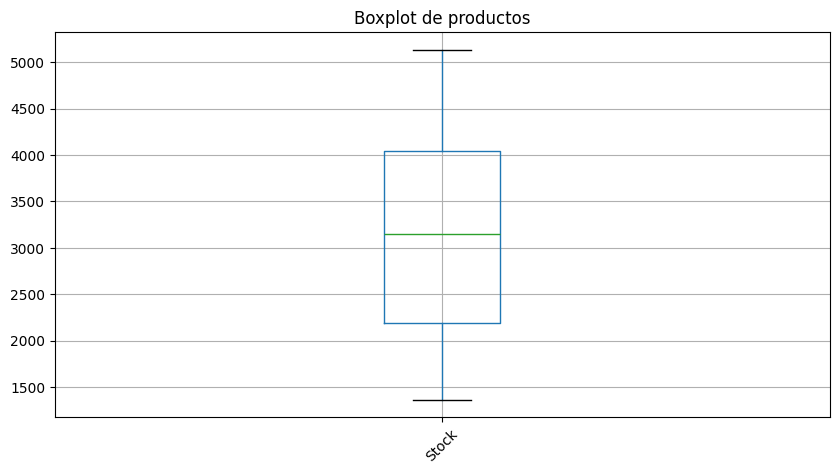

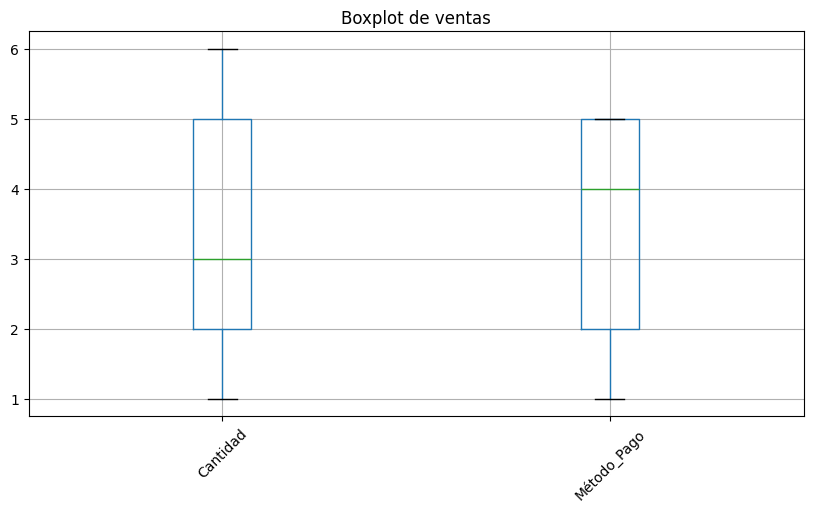

In [62]:
# Identificar valores atipicos por tabla usando boxplot pero excepto para ID_Cliente, ID_Producto, ID_Categoria, ID_Metodo_Pago
for nombre, tabla in tablas.items():
    columnas_numericas = tabla.select_dtypes(include=[np.number]).columns
    columnas_a_excluir = ['ID_Cliente', 'ID_Producto', 'ID_Categoria', 'ID_Metodo', 'ID_Venta']
    columnas_a_incluir = [col for col in columnas_numericas if col not in columnas_a_excluir]
    
    if len(columnas_a_incluir) > 0:
        plt.figure(figsize=(10, 5))
        tabla[columnas_a_incluir].boxplot()
        plt.title(f"Boxplot de {nombre}")
        plt.xticks(rotation=45)
        plt.show()

In [63]:
# Verificar fechas inconsistentes en ventas
import warnings


ventas['Fecha'] = pd.to_datetime(ventas['Fecha'], errors='coerce')
fechas_inconsistentes = ventas[ventas['Fecha'].isnull()]
print(f"Ventas con fechas inconsistentes: {len(fechas_inconsistentes)}")
# Evitar el UserWarning al convertir a datetime
warnings.filterwarnings('ignore')

Ventas con fechas inconsistentes: 0
